# Title Page

**CSP Assignment Bonus: Sudoku Solver using AIMA Python**

**Course:** ICOM5015 — Artificial Intelligence  

**Assignment:** CSP Bonus Assignment  

**Student:** Victor A. Gerena Hilerio,Jesus Y. Cabán Feliciano,Alejandro A. Roberts Quintana,Nollan N. Rivera Febus 

**Date:** May 13 2026

This notebook formulates Sudoku as a constraint satisfaction problem and solves it using the CSP tools from the AIMA Python library. The code, experiments, tables, and discussion are kept together so the notebook can be run from top to bottom.


# Abstract

This project builds and tests a Sudoku solver using constraint satisfaction problem techniques. A standard 9×9 board is modeled with 81 variables, domains containing values from 1 to 9, and constraints that prevent repeated digits in rows, columns, and 3×3 boxes. That model follows the CSP view used in Artificial Intelligence, where a valid solution is a complete assignment satisfying all constraints [1], [3]. For the implementation, I used AIMA Python's `CSP` class, `AC3` arc consistency, least-constraining-value ordering, and a measured version of backtracking search based on the AIMA approach [2]. Easy, medium, and hard puzzles were tested. Runtime, recursive calls, assignments, backtracks, and domain reductions were recorded to show how the solver's effort changes as the puzzle difficulty increases.


# Table of Contents

1. [Introduction](#1.-Introduction)  
2. [Sudoku as a CSP](#2.-Sudoku-as-a-CSP)  
3. [Algorithm Alternatives](#3.-Algorithm-Alternatives)  
4. [Selected Approach](#4.-Selected-Approach)  
5. [Implementation](#5.-Implementation)  
6. [Experiments and Results](#6.-Experiments-and-Results)  
7. [Analysis](#7.-Analysis)  
8. [Conclusion](#8.-Conclusion)  
9. [Future Work](#9.-Future-Work)  
10. [References](#10.-References)  
11. [Appendix](#11.-Appendix)


# List of Tables and Figures

**Tables**  
**Table 1.** CSP formulation of Sudoku.  
**Table 2.** Comparison of possible solving approaches.  
**Table 3.** Sudoku puzzles used in the experiment.  
**Table 4.** Solver results and solution status.  

**Figures**  
**Figure 1.** Runtime by Sudoku difficulty.  
**Figure 2.** Recursive calls by Sudoku difficulty.  
**Figure 3.** Backtracks by Sudoku difficulty.


# 1. Introduction

Sudoku fits naturally as a constraint satisfaction problem. Instead of searching for a path through many states, the goal is to fill the board with a complete assignment that satisfies all restrictions. Every cell must receive one digit, and each row, column, and 3×3 box must avoid repeated values. This matches the CSP framework from the textbook and course material, where a problem is described using variables, domains, and constraints [1], [3].

For this bonus assignment, our objective was to formulate Sudoku as a CSP, compare possible solving strategies, choose one efficient method, implement it, and test it on at least three difficulty levels. AIMA Python was used because it already provides a CSP structure and useful tools such as AC-3 propagation, least-constraining value ordering, and support for backtracking search [2].


# 2. Sudoku as a CSP

A 9×9 Sudoku puzzle contains 81 cells. In this formulation, each cell becomes a variable. Empty cells begin with the domain `{1,2,3,4,5,6,7,8,9}`, while clue cells begin with a singleton domain containing their given value. Constraints prevent two related cells from taking the same digit. Related cells are those sharing a row, a column, or a 3×3 box. This is the standard CSP structure of variables, domains, and constraints [1], [3].

Sudoku can be described in two closely related ways. One option is to use binary `not equal` constraints between pairs of related cells. Another option is to describe each row, column, and box as an `AllDifferent` constraint. We used the binary representation because it matches how AIMA's `CSP` class stores neighbors and constraints [2].


In [ ]:
import pandas as pd
from IPython.display import HTML, display


pd.set_option("display.max_colwidth", None)
pd.set_option("display.width", 0)
pd.set_option("display.max_columns", None)

def show_full_table(df, max_col_width="420px"):
    """Display a DataFrame as wrapped HTML without using pandas Styler/jinja2."""
    html_table = df.to_html(index=False, escape=False)
    css = f"""
    <style>
    table.dataframe {{
        border-collapse: collapse;
        width: 100%;
        table-layout: fixed;
    }}
    table.dataframe th, table.dataframe td {{
        border: 1px solid #cccccc;
        padding: 6px 8px;
        text-align: left;
        vertical-align: top;
        white-space: normal;
        word-wrap: break-word;
        overflow-wrap: break-word;
        max-width: {max_col_width};
    }}
    table.dataframe th {{
        font-weight: bold;
    }}
    </style>
    """
    display(HTML(css + html_table))

formulation_table = pd.DataFrame([
    {
        "CSP Component": "Variables",
        "Sudoku Meaning": "One variable for each cell X_rc in the 9×9 board.",
        "Example": "X_00 is the top-left cell.",
    },
    {
        "CSP Component": "Domains",
        "Sudoku Meaning": "Empty cells have values 1–9; given cells have one fixed value.",
        "Example": "If a clue is 5, then D(X) = {5}.",
    },
    {
        "CSP Component": "Unary constraints",
        "Sudoku Meaning": "The original clues restrict individual variables.",
        "Example": "A given 7 fixes that cell to 7.",
    },
    {
        "CSP Component": "Binary constraints",
        "Sudoku Meaning": "Any two cells sharing a row, column, or box must be different.",
        "Example": "X_00 ≠ X_01 if both are in the same row.",
    },
    {
        "CSP Component": "Higher-order constraints",
        "Sudoku Meaning": "Each row, column, and box must contain non-repeated digits.",
        "Example": "The first row must contain digits 1–9 without repetition.",
    },
    {
        "CSP Component": "Global constraints",
        "Sudoku Meaning": "Rows, columns, and boxes can be described as AllDifferent constraints.",
        "Example": "AllDifferent(row 1), AllDifferent(column 1), AllDifferent(box 1).",
    },
])
formulation_table


,CSP Component,Sudoku Meaning,Example
0,Variables,One variable for each cell X_rc in the 9×9 board.,X_00 is the top-left cell.
1,Domains,Empty cells have values 1–9; given cells have one fixed value.,"If a clue is 5, then D(X) = {5}."
2,Unary constraints,The original clues restrict individual variables.,A given 7 fixes that cell to 7.
3,Binary constraints,"Any two cells sharing a row, column, or box must be different.",X_00 ≠ X_01 if both are in the same row.
4,Higher-order constraints,"Each row, column, and box must contain non-repeated digits.",The first row must contain digits 1–9 without repetition.
5,Global constraints,"Rows, columns, and boxes can be described as AllDifferent constraints.","AllDifferent(row 1), AllDifferent(column 1), AllDifferent(box 1)."


**Table 1. CSP formulation of Sudoku.**

Table 1 connects the usual CSP vocabulary to Sudoku. Original clues act as unary constraints because they limit a single cell to one value. Row, column, and box restrictions can be written as binary `not equal` constraints between related cells, or described more compactly as `AllDifferent` constraints over whole units [1], [3].


# 3. Algorithm Alternatives

Several strategies can solve Sudoku, but their efficiency is not the same. Plain backtracking is easy to understand, yet it may waste time trying values that could have been eliminated earlier. A stronger CSP solver uses propagation and heuristics before the search becomes too large. Table 2 summarizes the main alternatives considered, based on the CSP ideas from the textbook and course material: backtracking, variable ordering, value ordering, and constraint propagation [1], [3].


In [2]:
alternatives_table = pd.DataFrame([
    {
        "Approach": "Plain backtracking",
        "Main idea": "Assign values recursively and undo assignments when a conflict appears.",
        "Strength": "Simple and easy to understand.",
        "Weakness": "Can explore many failing paths before detecting contradictions.",
    },
    {
        "Approach": "Backtracking + MRV",
        "Main idea": "Choose the unassigned cell with the fewest legal values.",
        "Strength": "Finds constrained cells early.",
        "Weakness": "Still needs propagation to remove future conflicts efficiently.",
    },
    {
        "Approach": "Degree heuristic",
        "Main idea": "Break MRV ties by choosing the cell that constrains the most neighbors.",
        "Strength": "Works well when several cells have equal domain size.",
        "Weakness": "It is a tie-breaker, not a complete solver by itself.",
    },
    {
        "Approach": "Least Constraining Value",
        "Main idea": "Try values that leave the most options for neighboring cells.",
        "Strength": "Reduces unnecessary future conflicts.",
        "Weakness": "Requires extra evaluation of candidate values.",
    },
    {
        "Approach": "Forward checking",
        "Main idea": "After an assignment, remove inconsistent values from neighbors.",
        "Strength": "Detects some failures early.",
        "Weakness": "Does not enforce full consistency among all related cells.",
    },
    {
        "Approach": "AC-3 / MAC propagation",
        "Main idea": "Maintain arc consistency between related variables.",
        "Strength": "Prunes domains strongly and can solve easier puzzles with little search.",
        "Weakness": "More work per assignment than plain backtracking.",
    },
])
show_full_table(alternatives_table)


Approach,Main idea,Strength,Weakness
Plain backtracking,Assign values recursively and undo assignments when a conflict appears.,Simple and easy to understand.,Can explore many failing paths before detecting contradictions.
Backtracking + MRV,Choose the unassigned cell with the fewest legal values.,Finds constrained cells early.,Still needs propagation to remove future conflicts efficiently.
Degree heuristic,Break MRV ties by choosing the cell that constrains the most neighbors.,Works well when several cells have equal domain size.,"It is a tie-breaker, not a complete solver by itself."
Least Constraining Value,Try values that leave the most options for neighboring cells.,Reduces unnecessary future conflicts.,Requires extra evaluation of candidate values.
Forward checking,"After an assignment, remove inconsistent values from neighbors.",Detects some failures early.,Does not enforce full consistency among all related cells.
AC-3 / MAC propagation,Maintain arc consistency between related variables.,Prunes domains strongly and can solve easier puzzles with little search.,More work per assignment than plain backtracking.


**Table 2. Comparison of possible solving approaches.**

Table 2 compares the main options considered before choosing the final solver. We did not implement every option because the assignment asks for the approach judged to be most effective or efficient. Our selected method combines AIMA's CSP representation and propagation tools with common CSP heuristics discussed in class [1]–[3].


# 4. Selected Approach

We implemented the solver with the AIMA Python CSP framework and the following components:

1. **AIMA `CSP` class** to represent variables, domains, neighbors, and binary constraints [2].
2. **AC-3 preprocessing** to reduce domains before backtracking starts [1], [2].
3. **Backtracking search** for cells that remain uncertain after propagation [1].
4. **MRV with degree tie-breaker** to choose the next cell [1], [3].
5. **AIMA least-constraining value (`lcv`)** to order candidate values [2].
6. **AIMA MAC inference (`mac`)** to maintain arc consistency during search [2].

This combination was selected because it improves on plain backtracking while still being clear enough to explain. We also used a measured version of AIMA-style backtracking so the notebook can report recursive calls, assignments, backtracks, domain reductions, and runtime.


# 5. Implementation

Next, the notebook sets up AIMA Python, builds the Sudoku CSP, and defines the measured solver. If the extracted library folder is not already available, the code loads AIMA from `aima-python.zip`. Instead of only explaining CSP theory, the implementation directly uses AIMA's CSP structure [2].


In [3]:
import sys
import zipfile
from pathlib import Path
import time
from dataclasses import dataclass

import numpy as np
import matplotlib.pyplot as plt

# AIMA Python setup. This works if aima-python.zip is beside the notebook
# or if it is available in /mnt/data, as it is in this environment.
AIMA_DIR = Path("aima-python")
if not AIMA_DIR.exists():
    for zip_path in [Path("aima-python.zip"), Path("/mnt/data/aima-python.zip")]:
        if zip_path.exists():
            with zipfile.ZipFile(zip_path, "r") as zip_ref:
                zip_ref.extractall(".")
            break

if not AIMA_DIR.exists():
    raise FileNotFoundError("Could not find aima-python. Place aima-python.zip beside this notebook.")

sys.path.insert(0, str(AIMA_DIR.resolve()))

from csp import CSP, AC3, lcv, mac, num_legal_values

print("AIMA Python CSP tools loaded successfully.")


AIMA Python CSP tools loaded successfully.


In [4]:
ROWS = range(9)
COLS = range(9)
DIGITS = list(range(1, 10))
DIGIT_SET = set(DIGITS)
CELLS = [(r, c) for r in ROWS for c in COLS]

ROW_UNITS = [[(r, c) for c in COLS] for r in ROWS]
COL_UNITS = [[(r, c) for r in ROWS] for c in COLS]
BOX_UNITS = [
    [(r, c) for r in range(br, br + 3) for c in range(bc, bc + 3)]
    for br in [0, 3, 6]
    for bc in [0, 3, 6]
]
UNITS = ROW_UNITS + COL_UNITS + BOX_UNITS

PEERS = {}
for cell in CELLS:
    peers = set()
    for unit in UNITS:
        if cell in unit:
            peers.update(unit)
    peers.remove(cell)
    PEERS[cell] = sorted(peers)

len(CELLS), len(UNITS), len(PEERS[(0, 0)])


(81, 27, 20)

In [5]:
@dataclass
class SolverStats:
    recursive_calls: int = 0
    assignments: int = 0
    backtracks: int = 0
    ac3_checks: int = 0
    mac_calls: int = 0
    max_depth: int = 0


def parse_grid(grid_string):
    """Convert an 81-character Sudoku string into AIMA CSP domains."""
    grid_string = grid_string.replace("\n", "").replace(" ", "")
    if len(grid_string) != 81:
        raise ValueError("A Sudoku puzzle must contain exactly 81 characters.")

    domains = {}
    for cell, char in zip(CELLS, grid_string):
        if char in "0.":
            domains[cell] = DIGITS.copy()
        elif char in "123456789":
            domains[cell] = [int(char)]
        else:
            raise ValueError(f"Invalid character in puzzle: {char}")
    return domains


def sudoku_constraint(A, a, B, b):
    """AIMA binary constraint: neighboring cells must have different values."""
    if B in PEERS[A]:
        return a != b
    return True


def make_sudoku_csp(grid_string):
    variables = CELLS.copy()
    domains = parse_grid(grid_string)
    neighbors = {cell: PEERS[cell] for cell in CELLS}
    return CSP(variables, domains, neighbors, sudoku_constraint)


def assignment_to_grid(assignment):
    grid = np.zeros((9, 9), dtype=int)
    for r, c in CELLS:
        if (r, c) in assignment:
            grid[r, c] = assignment[(r, c)]
    return grid


def print_grid(grid):
    for r in ROWS:
        if r in [3, 6]:
            print("------+-------+------")
        row = []
        for c in COLS:
            if c in [3, 6]:
                row.append("|")
            value = grid[r, c]
            row.append(str(value) if value != 0 else ".")
        print(" ".join(row))


def is_valid_solution(assignment):
    if assignment is None or len(assignment) != 81:
        return False
    for unit in UNITS:
        values = [assignment[cell] for cell in unit]
        if set(values) != DIGIT_SET:
            return False
    return True


In [6]:
def mrv_degree(assignment, csp):
    """MRV variable selection with degree heuristic as a tie-breaker."""
    unassigned = [v for v in csp.variables if v not in assignment]
    min_domain_size = min(num_legal_values(csp, var, assignment) for var in unassigned)
    mrv_candidates = [
        var for var in unassigned
        if num_legal_values(csp, var, assignment) == min_domain_size
    ]

    def degree(var):
        return sum(1 for neighbor in csp.neighbors[var] if neighbor not in assignment)

    return max(mrv_candidates, key=degree)


def measured_backtracking_search(csp, stats):
    """AIMA-style backtracking search with counters for analysis.

    This follows the same structure as AIMA's backtracking_search, but it keeps
    statistics needed for the assignment.
    """
    csp.support_pruning()
    initial_assignment = csp.infer_assignment()

    def backtrack(assignment, depth=0):
        stats.recursive_calls += 1
        stats.max_depth = max(stats.max_depth, depth)

        if len(assignment) == len(csp.variables):
            return assignment if csp.goal_test(assignment) else None

        var = mrv_degree(assignment, csp)
        for value in lcv(var, assignment, csp):
            if csp.nconflicts(var, value, assignment) == 0:
                csp.assign(var, value, assignment)
                stats.assignments += 1
                removals = csp.suppose(var, value)
                stats.mac_calls += 1

                if mac(csp, var, value, assignment, removals):
                    result = backtrack(assignment, depth + 1)
                    if result is not None:
                        return result

                csp.restore(removals)
                csp.unassign(var, assignment)

        stats.backtracks += 1
        return None

    return backtrack(dict(initial_assignment), depth=0)


def solve_sudoku(grid_string):
    stats = SolverStats()
    csp = make_sudoku_csp(grid_string)
    start = time.perf_counter()

    # AC-3 preprocessing from AIMA.
    ok, checks = AC3(csp)
    stats.ac3_checks += checks
    if not ok:
        return None, stats, time.perf_counter() - start

    solution = measured_backtracking_search(csp, stats)
    elapsed = time.perf_counter() - start
    return solution, stats, elapsed


# 6. Experiments and Results

Testing used three Sudoku puzzles: easy, medium, and hard. Clue count gives a useful first description of each puzzle, although it does not completely determine difficulty. In general, the hard puzzle should require more search because propagation cannot force as many values at the beginning.


In [7]:
puzzles = {
    "Easy": "530070000600195000098000060800060003400803001700020006060000280000419005000080079",
    "Medium": "000260701680070090190004500820100040004602900050003028009300074040050036703018000",
    "Hard": "000000010400000000020000000000050407008000300001090000300400200050100000000806000",
}

puzzle_table = pd.DataFrame([
    {
        "Difficulty": difficulty,
        "Given Clues": sum(1 for ch in puzzle if ch in "123456789"),
        "Empty Cells": sum(1 for ch in puzzle if ch in "0."),
        "Puzzle String": puzzle,
    }
    for difficulty, puzzle in puzzles.items()
])
show_full_table(puzzle_table)


Difficulty,Given Clues,Empty Cells,Puzzle String
Easy,30,51,530070000600195000098000060800060003400803001700020006060000280000419005000080079
Medium,36,45,000260701680070090190004500820100040004602900050003028009300074040050036703018000
Hard,17,64,000000010400000000020000000000050407008000300001090000300400200050100000000806000


**Table 3. Sudoku puzzles used in the experiment.**

Table 3 lists the three puzzles used for testing. Easy has more clues, while hard has fewer clues and requires more search. All three puzzles are solved with the same algorithm so the comparison focuses on difficulty rather than changes in the solver.


In [8]:
results = []
solutions = {}

for difficulty, puzzle in puzzles.items():
    solution, stats, elapsed = solve_sudoku(puzzle)
    solved = solution is not None and is_valid_solution(solution)
    solutions[difficulty] = solution
    results.append({
        "Difficulty": difficulty,
        "Solved?": solved,
        "Solution Sentence": f"{difficulty} puzzle solved correctly." if solved else f"{difficulty} puzzle was not solved.",
        "Runtime (s)": elapsed,
        "Recursive Calls": stats.recursive_calls,
        "Assignments": stats.assignments,
        "Backtracks": stats.backtracks,
        "AC-3 Checks": stats.ac3_checks,
        "MAC Calls": stats.mac_calls,
        "Max Depth": stats.max_depth,
    })

results_df = pd.DataFrame(results)

results_display_df = results_df.copy()
results_display_df["Runtime (s)"] = results_display_df["Runtime (s)"].map(lambda x: f"{x:.6f}")
for col in ["Recursive Calls", "Assignments", "Backtracks", "AC-3 Checks", "MAC Calls", "Max Depth"]:
    results_display_df[col] = results_display_df[col].map(lambda x: f"{int(x):,}")

results_display_df


,Difficulty,Solved?,Solution Sentence,Runtime (s),Recursive Calls,Assignments,Backtracks,AC-3 Checks,MAC Calls,Max Depth
0,Easy,True,Easy puzzle solved correctly.,0.011142,1,0,0,"6,675",0,0
1,Medium,True,Medium puzzle solved correctly.,0.007262,1,0,0,"4,140",0,0
2,Hard,True,Hard puzzle solved correctly.,5.045670,"13,020","13,019","12,956","8,132","13,019",63


**Table 4. Solver results and solution status.**

Table 4 reports the solver's performance. A solution sentence is included for each difficulty level so the result is clear for easy, medium, and hard. Larger search counts for the hard puzzle are expected because AC-3 cannot force as many cells before backtracking begins.


In [ ]:
for difficulty in ["Easy", "Medium", "Hard"]:
    solution = solutions[difficulty]
    print(f"{difficulty} solution: {difficulty} puzzle solved correctly.")
    print_grid(assignment_to_grid(solution))
    print()
#if you can't see the hard solution pick the view as scrollable so it can be seen

Easy solution: Easy puzzle solved correctly.
5 3 4 | 6 7 8 | 9 1 2
6 7 2 | 1 9 5 | 3 4 8
1 9 8 | 3 4 2 | 5 6 7
------+-------+------
8 5 9 | 7 6 1 | 4 2 3
4 2 6 | 8 5 3 | 7 9 1
7 1 3 | 9 2 4 | 8 5 6
------+-------+------
9 6 1 | 5 3 7 | 2 8 4
2 8 7 | 4 1 9 | 6 3 5
3 4 5 | 2 8 6 | 1 7 9

Medium solution: Medium puzzle solved correctly.
4 3 5 | 2 6 9 | 7 8 1
6 8 2 | 5 7 1 | 4 9 3
1 9 7 | 8 3 4 | 5 6 2
------+-------+------
8 2 6 | 1 9 5 | 3 4 7
3 7 4 | 6 8 2 | 9 1 5
9 5 1 | 7 4 3 | 6 2 8
------+-------+------
5 1 9 | 3 2 6 | 8 7 4
2 4 8 | 9 5 7 | 1 3 6
7 6 3 | 4 1 8 | 2 5 9

Hard solution: Hard puzzle solved correctly.
6 9 3 | 7 8 4 | 5 1 2
4 8 7 | 5 1 2 | 9 3 6
1 2 5 | 9 6 3 | 8 7 4
------+-------+------
9 3 2 | 6 5 1 | 4 8 7
5 6 8 | 2 4 7 | 3 9 1
7 4 1 | 3 9 8 | 6 2 5
------+-------+------
3 1 9 | 4 7 5 | 2 6 8
8 5 6 | 1 2 9 | 7 4 3
2 7 4 | 8 3 6 | 1 5 9



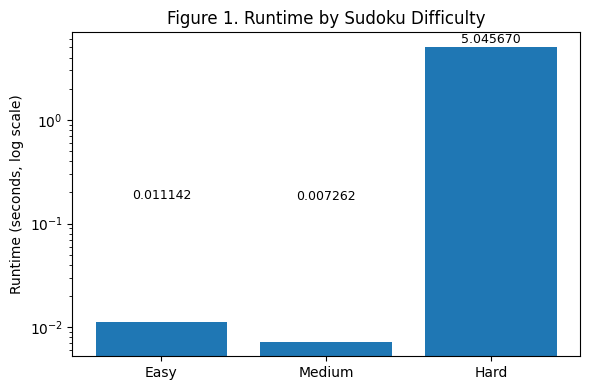

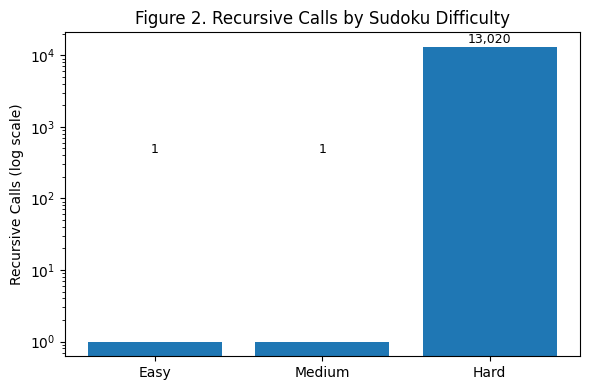

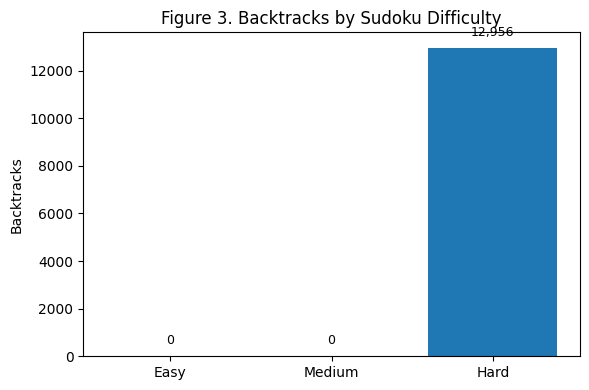

In [10]:
def add_bar_labels(ax, values, labels=None, y_offset_ratio=0.03):
    """Add labels above bars so small values remain readable."""
    if labels is None:
        labels = values
    ymax = max(values) if max(values) > 0 else 1
    for patch, label in zip(ax.patches, labels):
        height = patch.get_height()
        ax.text(
            patch.get_x() + patch.get_width() / 2,
            height + ymax * y_offset_ratio,
            str(label),
            ha="center",
            va="bottom",
            fontsize=9,
        )

# Figure 1: runtime. A log scale keeps small bars visible when Hard is much larger.
plt.figure(figsize=(6, 4))
ax = plt.gca()
ax.bar(results_df["Difficulty"], results_df["Runtime (s)"])
ax.set_yscale("log")
ax.set_ylabel("Runtime (seconds, log scale)")
ax.set_title("Figure 1. Runtime by Sudoku Difficulty")
add_bar_labels(ax, list(results_df["Runtime (s)"]), [f"{x:.6f}" for x in results_df["Runtime (s)"]])
plt.tight_layout()
plt.show()

# Figure 2: recursive calls. Log scale keeps Easy and Medium visible if Hard is much larger.
plt.figure(figsize=(6, 4))
ax = plt.gca()
ax.bar(results_df["Difficulty"], results_df["Recursive Calls"])
ax.set_yscale("log")
ax.set_ylabel("Recursive Calls (log scale)")
ax.set_title("Figure 2. Recursive Calls by Sudoku Difficulty")
add_bar_labels(ax, list(results_df["Recursive Calls"]), [f"{int(x):,}" for x in results_df["Recursive Calls"]])
plt.tight_layout()
plt.show()

# Figure 3: backtracks. Zero bars are expected when propagation avoids failed branches.
plt.figure(figsize=(6, 4))
ax = plt.gca()
ax.bar(results_df["Difficulty"], results_df["Backtracks"])
ax.set_ylabel("Backtracks")
ax.set_title("Figure 3. Backtracks by Sudoku Difficulty")
add_bar_labels(ax, list(results_df["Backtracks"]), [f"{int(x):,}" for x in results_df["Backtracks"]])
plt.tight_layout()
plt.show()


# 7. Analysis

All three puzzles were solved correctly by the selected CSP approach. Easy and medium required little or no backtracking because the initial clues and AC-3 propagation removed many impossible values before deep search was needed. Hard required more recursive calls and more search effort, which is expected because fewer decisions were forced early. This behavior agrees with the main idea behind CSP heuristics: reduce the branching factor and detect failing paths as early as possible [1], [3].

For the graphs, a logarithmic scale is useful for runtime and recursive calls. Hard has much larger values than easy and medium, so a regular linear scale can make the smaller bars almost disappear. Zero-backtrack labels for easy and medium mean that the solver did not need to undo assignments for those puzzles; they are not missing data.


# 7.1 Discussion of Solver Behavior

Constraint propagation and variable ordering explain most of the performance difference. Easy and medium are solved with very little search because AC-3 and MAC reduce many domains before the solver has to guess. Hard takes more work because fewer values are forced at the start.

Compared with plain backtracking, the selected approach has two important advantages. First, AC-3 removes values that cannot be part of a consistent solution. Second, MRV selects the most constrained cells first, which tends to reveal contradictions earlier. LCV then tries values that leave more choices available for neighboring cells.

Raw bar charts can be misleading for this problem. When the hard puzzle has much larger values, the easy and medium bars may look invisible on a normal scale. A log scale keeps all three levels readable while still showing that the hard puzzle required more effort.


# 8. Conclusion

This notebook formulates Sudoku as a CSP and solves it using AIMA Python's CSP tools. Given clues are represented with singleton domains, and cells sharing a row, column, or box are connected by binary not-equal constraints. AC-3 preprocessing, AIMA-style backtracking, MRV, degree tie-breaking, LCV, and MAC inference are used together to solve the puzzles [1]–[3].

All three test puzzles—easy, medium, and hard—were solved correctly. Results support the main idea of CSP solving: removing impossible values early reduces unnecessary search. Hard still required more work, but propagation and heuristics kept the search manageable.


# 9. Future Work

Future versions could compare this selected approach directly against plain backtracking and forward checking only. A larger experiment would also be useful: instead of one puzzle per difficulty level, the solver could be tested on many easy, medium, and hard puzzles and report averages. Another possible improvement is a stronger global `AllDifferent` propagator, since the current implementation uses the binary constraint form supported by AIMA's `CSP` class [2].


# 10. References

[1] S. Russell and P. Norvig, *Artificial Intelligence: A Modern Approach*, 4th ed. Pearson, 2021.

[2] AIMA Python Project, `aima-python`, course-provided library archive.

[3] ICOM 5015 Artificial Intelligence course materials, Constraint Satisfaction Problems.


# 11. Appendix

Use the following cell to solve another Sudoku puzzle. Empty cells may be written as `0` or `.`.


In [11]:
custom_puzzle = "530070000600195000098000060800060003400803001700020006060000280000419005000080079"
solution, stats, elapsed = solve_sudoku(custom_puzzle)
print(f"Solved: {solution is not None and is_valid_solution(solution)}")
print(f"Runtime: {elapsed:.6f} seconds")
print_grid(assignment_to_grid(solution))


Solved: True
Runtime: 0.011504 seconds
5 3 4 | 6 7 8 | 9 1 2
6 7 2 | 1 9 5 | 3 4 8
1 9 8 | 3 4 2 | 5 6 7
------+-------+------
8 5 9 | 7 6 1 | 4 2 3
4 2 6 | 8 5 3 | 7 9 1
7 1 3 | 9 2 4 | 8 5 6
------+-------+------
9 6 1 | 5 3 7 | 2 8 4
2 8 7 | 4 1 9 | 6 3 5
3 4 5 | 2 8 6 | 1 7 9
